In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the CSV
def load(file):
    df = pd.read_csv(file)
    df["method"] = df["iteration"].apply(lambda x: "vanilla_rag" if x == 1 else "query_expansion")
    df = df[-6:]
    return df

df = load("metrics.csv")
df_prev = load("metrics_no_citation.csv")

df

,iteration,avg_ndcg,avg_ndcg_filtered,avg_recall,filtered_size,question_set,method
0,1,0.6456,0.7714,0.6850,65,2hop,vanilla_rag
1,2,0.6836,0.8335,0.8000,65,2hop,query_expansion
2,1,0.5633,0.7608,0.5600,17,3hop,vanilla_rag
3,2,0.5658,0.7833,0.6267,17,3hop,query_expansion
4,1,0.4268,0.5971,0.3575,4,4hop,vanilla_rag
5,2,0.4305,0.9450,0.4400,4,4hop,query_expansion


In [13]:
def plot(df, ver="Citation-Enhanced"):
    df = df.copy()
    df["method"] = df["iteration"].apply(lambda x: "vanilla_rag" if x == 1 else "query_expansion")

    # Melt for plotting
    melted_df = df.melt(
        id_vars=["method", "question_set", "filtered_size"],
        value_vars=["avg_ndcg", "avg_ndcg_filtered", "avg_recall"],
        var_name="metric",
        value_name="score"
    )

    sns.set(style="whitegrid")
    metrics = ["avg_ndcg", "avg_ndcg_filtered", "avg_recall"]
    titles = {
        "avg_ndcg": "Average NDCG",
        "avg_ndcg_filtered": "Filtered NDCG (Recall = 1)",
        "avg_recall": "Average Recall",
    }

    fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

    for i, metric in enumerate(metrics):
        ax = axes[i]
        subset = melted_df[melted_df["metric"] == metric]

        sns.barplot(
            data=subset,
            x="question_set", y="score", hue="method",
            errorbar=None, palette="Set2", edgecolor="black", dodge=True, ax=ax
        )

        # Add score labels
        for container in ax.containers:
            for bar in container:
                height = bar.get_height()
                if height > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        height + 0.01,
                        f"{height:.3f}",
                        ha="center", va="bottom", fontsize=9
                    )

        # Annotate filtered size only on filtered NDCG plot
        if metric == "avg_ndcg_filtered":
            # Use the original df, grouped by method and question_set
            for _, row in df.iterrows():
                xpos = list(df["question_set"].unique()).index(row["question_set"])
                offset = -0.2 if row["method"] == "vanilla_rag" else 0.2
                ax.text(
                    xpos + offset,
                    0.05,
                    f"n={int(row['filtered_size'])}",
                    ha="center", va="bottom", fontsize=8, color="gray", weight="bold"
                )

        ax.set_title(titles[metric])
        ax.set_xlabel("Question Set")
        if i == 0:
            ax.set_ylabel("Score")
        else:
            ax.set_ylabel("")
        ax.set_ylim(0, 1)
        ax.legend(title="Method", loc="upper right", frameon=True)

    fig.suptitle(f"Comparison of RAG Methods by Question Set ({ver})", fontsize=14, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

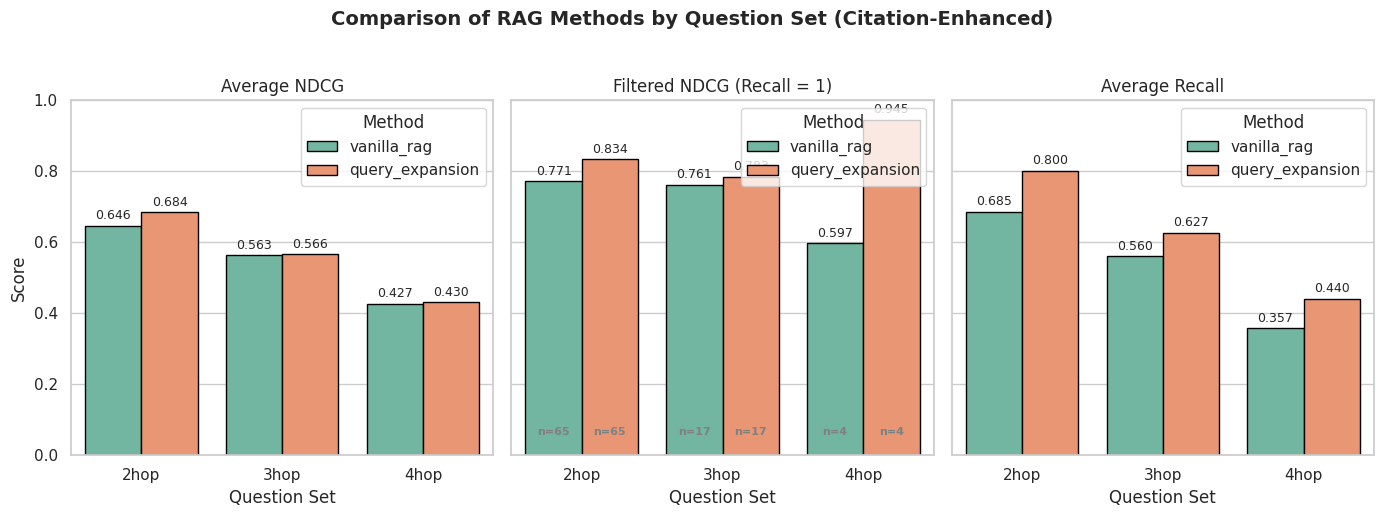

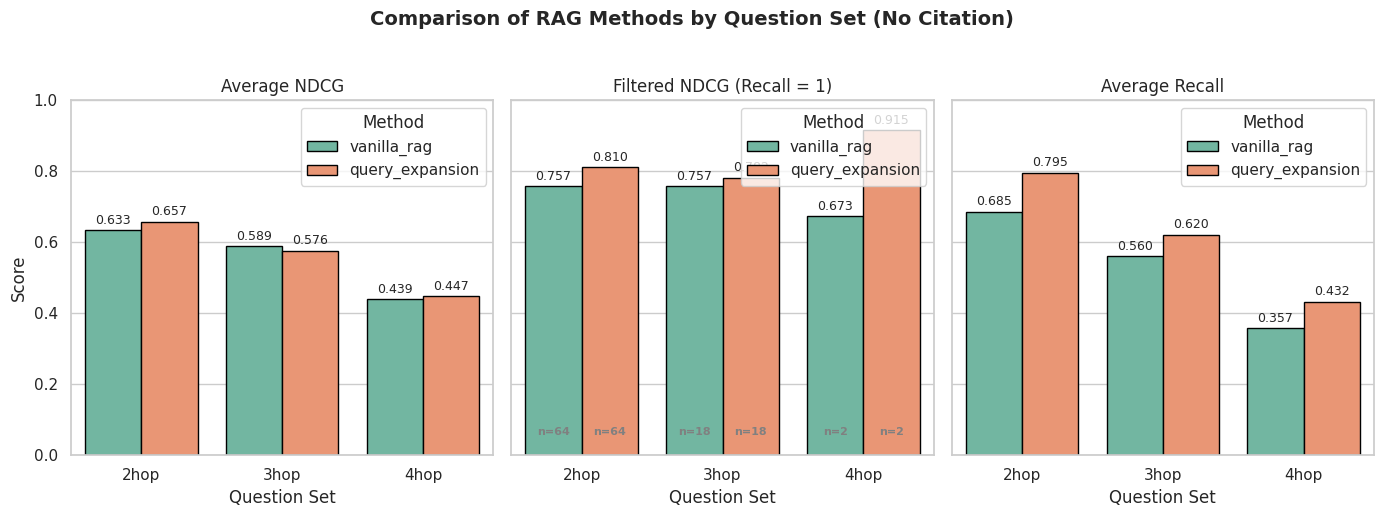

In [14]:
plot(df)
plot(df_prev, "No Citation")